In [1]:
import numpy as np
import pandas as pd
from pipedream_solver.hydraulics import SuperLink
from pipedream_solver.nquality import QualityBuilder
from pipedream_solver.simulation import Simulation
import matplotlib.pyplot as plt
import time

In [2]:
input_path = '../data/hillslope_wq'
superjunctions = pd.read_csv(f'{input_path}/Simple_superjunctions.csv')
superlinks = pd.read_csv(f'{input_path}/Simple_superlinks.csv')
superlink_wq_params = pd.read_csv(f'{input_path}/Simple_superlink_wq_params.csv')
superjunction_wq_params = pd.read_csv(f'{input_path}/Simple_superjunction_wq_params.csv')

# input boundary 
H_bc = pd.read_csv(f'{input_path}/Simple_boundary_stage.csv', index_col=0)

In [3]:
# Set scenarios
No_internal_link_list = [20, 50, 100, 500]
dt_list = [60, 25, 10, 1]  # do not change this list's order: causes error in making figures


In [4]:
c_ik_out_dx = {}
c_ik_out_dt = {}
for dt_ in dt_list:
    c_ik = []
    for No_link in No_internal_link_list:    
        internal_links = No_link
        superlink = SuperLink(superlinks, superjunctions, internal_links=internal_links)
        WQ = QualityBuilder(superlink, superjunction_params=superjunction_wq_params,
                                      superlink_params=superlink_wq_params)
        T_max = 1200
        C_start = 0
        C_end = 1200
        C_input = 10
        Q_0Ik = 0*np.ones(superlink.NIk)
        c_ik = []
        
        start_t = time.perf_counter()
        with Simulation(superlink, dt=dt_, H_bc=H_bc) as simulation:
            coeffs = simulation.h0321
            
            while simulation.t <= T_max:
                # setting the contaminant input duration
                if (superlink.t > C_start) and (superlink.t <= C_end):
                    # Apply contaminant to uphill superjunction
                    Q_in = 0.5 * np.asarray([1.,0.])
                    c_0j = C_input * np.asarray([1., 0.])
                else:     # Otherwise, no contaminant input
                    Q_in = 0.5 * np.asarray([1.,0.])
                    c_0j = np.zeros(2)
                    
                # Advance hydraulic model
                superlink.step(dt=dt_, Q_in=Q_in, Q_0Ik=Q_0Ik)
                
                # Advance water quality model
                WQ.step(dt=dt_, c_0j=c_0j)
                
                # Record nodal contaminant concentrations
                c_ik.append(WQ.c_ik.copy())
        c_ik_out_dx[No_link] = c_ik
    c_ik_out_dt[dt_] = c_ik

In [5]:
# Analytical solution: time series
from scipy import special
K = WQ._K_ik[1]                                  # Reaction
D = WQ._D_ik[1]                                  # Diffusion coefficient
Vx = np.mean(superlink.Q_ik[1:1000]/superlink.A_ik[1:1000])    # velocity
x = np.linspace(1,1000,1000)
Gamma = np.sqrt(1+(4*K*D/pow(Vx,2)))
tau = C_end - 0.0000001
C0 = C_input

#Analytical solution: spatial
t = T_max
tau = C_end - 0.0000001

X_location = np.zeros(1000)
X_location[0] = superlink._dx_ik[1]/2
C_Analytical_space = np.zeros(1000)

X_location = x
for i in range(0,1000): 
    C_An_Temp = special.erfc((X_location[i]-Vx*t*Gamma)/(2*np.sqrt(D*t)))
    C_An_Temp += -special.erfc((X_location[i]-Vx*(t-tau)*Gamma)/(2*np.sqrt(D*(t-tau))))
    C_Analytical_space[i] = 0.5*C0*np.exp(Vx*X_location[i]*(1-Gamma)/(2*D))*C_An_Temp
    C_An_Temp = special.erfc((X_location[i]+Vx*t*Gamma)/(2*np.sqrt(D*t)))
    C_An_Temp += -special.erfc((X_location[i]+Vx*(t-tau)*Gamma)/(2*np.sqrt(D*(t-tau))))
    C_Analytical_space[i] += np.exp(Vx*X_location[i]*(1+Gamma)/(2*D)) * C_An_Temp

<Figure size 640x480 with 0 Axes>

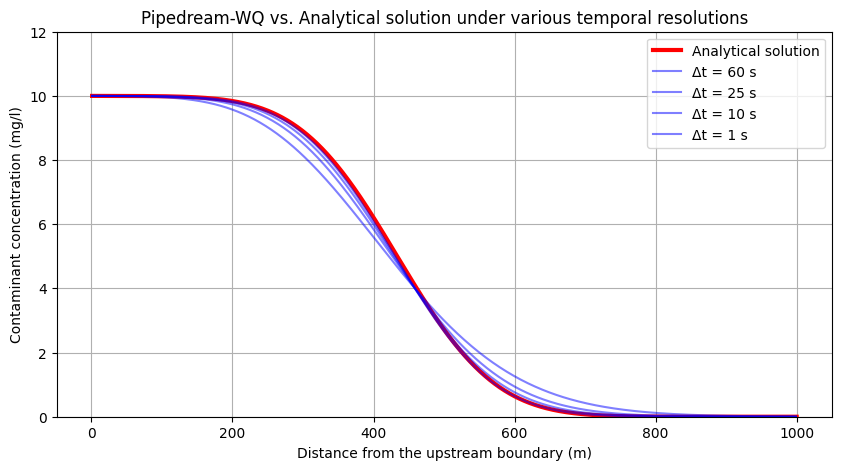

In [6]:
# Print the results: for dt
plt.figure()
plt.figure(figsize= (10,5))
plt.plot(x,C_Analytical_space, color = 'r', linewidth = 3, label = 'Analytical solution')
for dt_ in dt_list:
    No_link = 500
    s2 = np.linspace(0.5*1000/No_link, 0.5*1000/No_link + 1000*(No_link-1)/No_link,No_link)
    c_ik = np.array(c_ik_out_dt[dt_])
    plt.plot(s2, c_ik[int(T_max/dt_), 0:No_link+1], '-', color = 'b', linewidth = 1.5, alpha = 0.5, label = f'Δt = {dt_} s')
plt.title('Pipedream-WQ vs. Analytical solution under various temporal resolutions')
plt.ylim(0,12)
plt.xlabel('Distance from the upstream boundary (m)')
plt.ylabel('Contaminant concentration (mg/l)')
plt.legend()
plt.grid()

<Figure size 640x480 with 0 Axes>

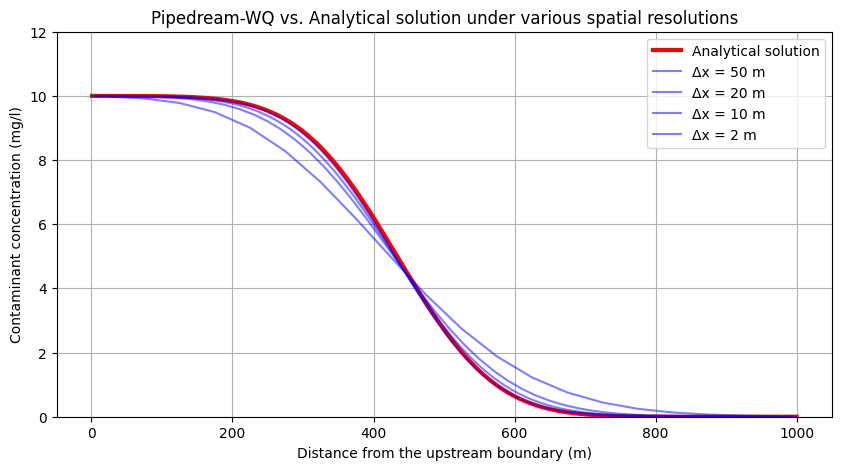

In [7]:
# Print the results: for dx
plt.figure()
plt.figure(figsize= (10,5))
plt.plot(x,C_Analytical_space, color = 'r', linewidth = 3, label = 'Analytical solution')
for No_link in No_internal_link_list:
    s2 = np.linspace(0.5*1000/No_link, 0.5*1000/No_link + 1000*(No_link-1)/No_link,No_link)
    c_ik = np.array(c_ik_out_dx[No_link])
    label_ = int(1000/No_link)
    plt.plot(s2, c_ik[T_max, 0:No_link+1], '-', color = 'b', linewidth = 1.5, alpha = 0.5, label = f'Δx = {label_} m')
plt.title('Pipedream-WQ vs. Analytical solution under various spatial resolutions')
plt.ylim(0,12)
plt.xlabel('Distance from the upstream boundary (m)')
plt.ylabel('Contaminant concentration (mg/l)')
plt.legend()
plt.grid()
plt.show()
